In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.func import grad
import scipy
import scipy.special
import scipy.linalg
from scipy.linalg import toeplitz, cholesky
from gaussian_crossings import simulate_gaussian_process_fft, simulate_gaussian_process_cholesky, GaussianUpcrossings

In [2]:
def r_squared_exp(t, tau, sigma):
        return sigma**2 * torch.exp(- (t / tau)**2)

# Define parameters (as tensors if you wish them to be differentiable)
tau   = 1.0
sigma = 1.0


In [3]:
u = 1.0
model = GaussianUpcrossings(r_func=r_squared_exp, u=u, tau=tau, sigma=sigma)


In [4]:
t = torch.linspace(0.02, 10, 1000)

alpha, beta, gamma, delta = model.compute_all_quantities(t, u)

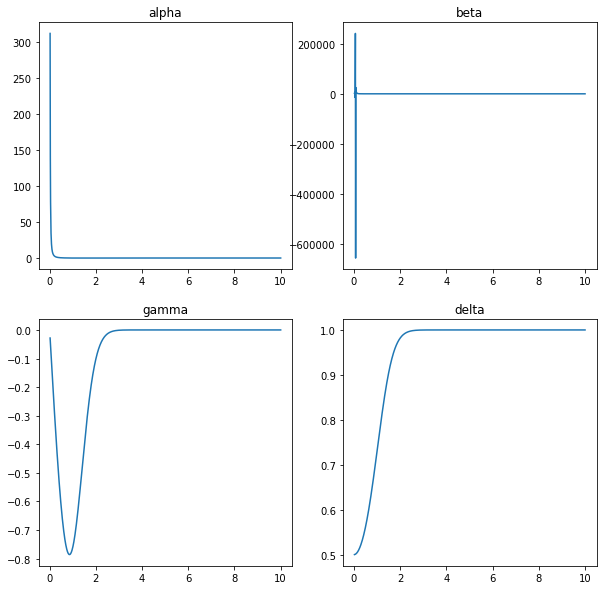

In [5]:
# plot all alpha beta on separate subplots
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].plot(t, alpha)
ax[0, 0].set_title("alpha")
ax[0, 1].plot(t, beta)
ax[0, 1].set_title("beta")
ax[1, 0].plot(t, gamma)
ax[1, 0].set_title("gamma")
ax[1, 1].plot(t, delta)
ax[1, 1].set_title("delta")
plt.show()

Now we test the behavior of the various expressions that appear in the solution.

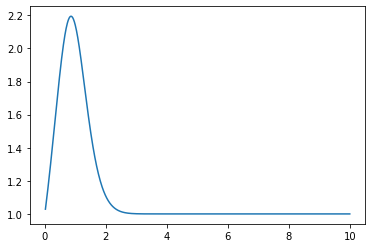

In [6]:
expr = torch.exp(- gamma * u**2)
plt.plot(t, expr)
plt.show()

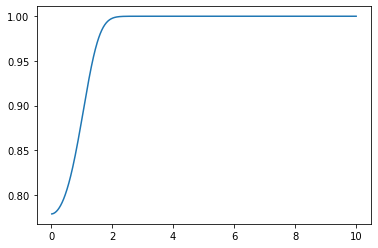

In [7]:
expr = torch.exp(- alpha * gamma**2)
plt.plot(t, expr)
plt.show()

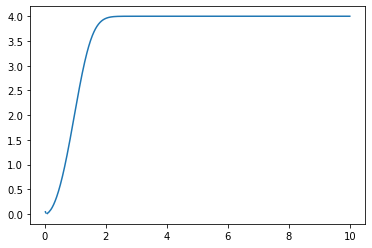

In [8]:
expr = 1 / (torch.sqrt((model.r0 ** 2 - model.r(t)**2) * (alpha * beta)))
plt.plot(t, expr)
plt.show()

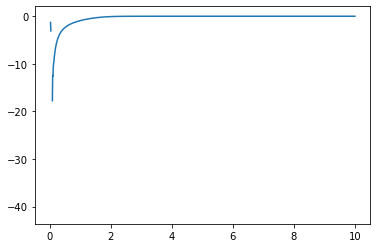

In [9]:
expr = gamma * torch.sqrt(alpha + beta)
plt.plot(t, expr)
plt.show()

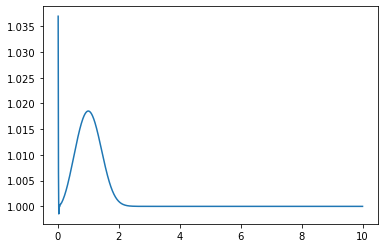

In [10]:
expr = torch.exp(alpha ** 2 * gamma ** 2 / (alpha + beta))
plt.plot(t, expr)
plt.show()

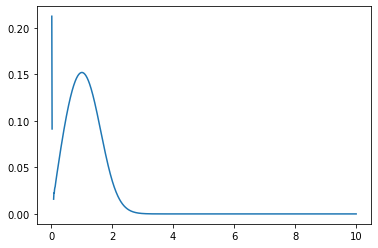

In [11]:
expr = torch.special.erf(torch.sqrt(alpha ** 2 * gamma ** 2 / (alpha + beta)))
plt.plot(t, expr)
plt.show()

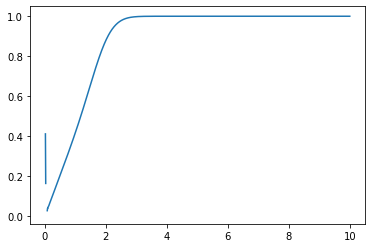

In [12]:
expr = torch.sqrt(alpha / beta)
plt.plot(t, expr)
plt.show()

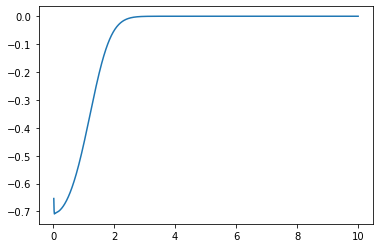

In [13]:
expr = gamma * torch.sqrt(2 * alpha * beta / (alpha + beta))
plt.plot(t, expr)
plt.show()

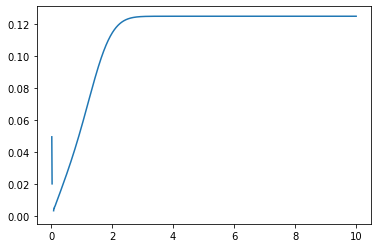

In [14]:
expr = scipy.special.owens_t(gamma * torch.sqrt(2 * alpha * beta / (alpha + beta)), torch.sqrt(alpha / beta))
plt.plot(t, expr)
plt.show()

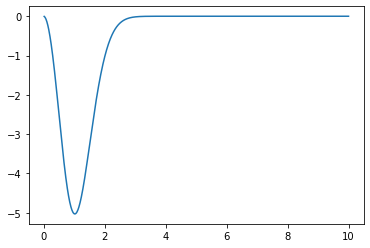

In [15]:
expr = (alpha - beta - 2 * alpha * beta * gamma ** 2) / (alpha * beta)
plt.plot(t, expr)
plt.show()